In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 1.5 MB/s eta 0:00:02
   -------------- ------------------------- 0.8/2.2 MB 1.6 MB/s eta 0:00:01
   ------------------ --------------------- 1.0/2.2 MB 1.7 MB/s eta 0:00:01
   ----------------------- ---------------- 1.3/2.2 MB 1.6 MB/s eta 0:00:01
   -------------------------------- ------- 1.8/2.2 MB 1.6 MB/s eta 0:00:01
   ------------------------------------- -- 2.1/2.2 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 1.6 MB/s eta 0:00:00

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv("Crop_recommendation.csv")

In [3]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df.shape

(2200, 8)

In [5]:
df.info
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [7]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

In [10]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [11]:
df.describe

<bound method NDFrame.describe of         N   P   K  temperature   humidity        ph    rainfall   label
0      90  42  43    20.879744  82.002744  6.502985  202.935536    rice
1      85  58  41    21.770462  80.319644  7.038096  226.655537    rice
2      60  55  44    23.004459  82.320763  7.840207  263.964248    rice
3      74  35  40    26.491096  80.158363  6.980401  242.864034    rice
4      78  42  42    20.130175  81.604873  7.628473  262.717340    rice
...   ...  ..  ..          ...        ...       ...         ...     ...
2195  107  34  32    26.774637  66.413269  6.780064  177.774507  coffee
2196   99  15  27    27.417112  56.636362  6.086922  127.924610  coffee
2197  118  33  30    24.131797  67.225123  6.362608  173.322839  coffee
2198  117  32  34    26.272418  52.127394  6.758793  127.175293  coffee
2199  104  18  30    23.603016  60.396475  6.779833  140.937041  coffee

[2200 rows x 8 columns]>

In [12]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [13]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nCrop classes:")
print(df["label"].unique())

print("\nNumber of crops:")
print(df["label"].nunique())

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows:
0

Crop classes:
<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

Number of crops:
22


In [14]:
X = df.drop("label", axis=1)
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2200, 7)
y shape: (2200,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1760, 7)
Testing data: (440, 7)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [18]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:10])

['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange']


In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

Accuracy: 0.9727272727272728
Accuracy percentage: 97.27272727272728


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97        20
      papaya       1.00    

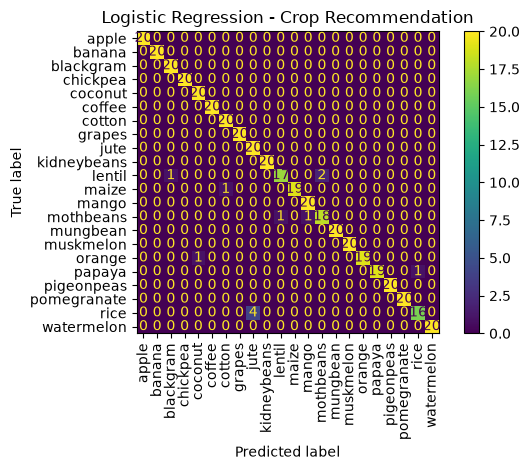

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90
)

plt.title("Logistic Regression - Crop Recommendation")
plt.tight_layout()
plt.show()

In [22]:
new_data = [[90, 42, 43, 20.8, 82.0, 6.5, 202.9]]

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("Recommended crop:", prediction[0])

Recommended crop: rice


C:\Users\dhaka\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
probabilities = model.predict_proba(new_data_scaled)

classes = model.classes_

for crop, probability in zip(classes, probabilities[0]):
    print(f"{crop}: {probability:.4f}")

apple: 0.0003
banana: 0.0004
blackgram: 0.0000
chickpea: 0.0000
coconut: 0.0008
coffee: 0.0080
cotton: 0.0012
grapes: 0.0000
jute: 0.2248
kidneybeans: 0.0000
lentil: 0.0000
maize: 0.0023
mango: 0.0000
mothbeans: 0.0000
mungbean: 0.0000
muskmelon: 0.0000
orange: 0.0001
papaya: 0.0009
pigeonpeas: 0.0002
pomegranate: 0.0002
rice: 0.7598
watermelon: 0.0010


In [28]:

import ipywidgets as widgets
from IPython.display import display

# Input fields
N = widgets.FloatText(description='Nitrogen:')
P = widgets.FloatText(description='Phosphorus:')
K = widgets.FloatText(description='Potassium:')
temperature = widgets.FloatText(description='Temperature:')
humidity = widgets.FloatText(description='Humidity:')
ph = widgets.FloatText(description='pH:')
rainfall = widgets.FloatText(description='Rainfall:')

button = widgets.Button(description='Predict Crop')

output = widgets.Output()

def predict_crop(b):
    with output:
        output.clear_output()

        # Take user input
        new_data = [[
            N.value,
            P.value,
            K.value,
            temperature.value,
            humidity.value,
            ph.value,
            rainfall.value
        ]]

        # Scale input
        new_data_scaled = scaler.transform(new_data)

        # Prediction
        prediction = model.predict(new_data_scaled)

        print("🌱 Recommended Crop:", prediction[0])

button.on_click(predict_crop)

display(
    N, P, K,
    temperature,
    humidity,
    ph,
    rainfall,
    button,
    output
)

FloatText(value=0.0, description='Nitrogen:')

FloatText(value=0.0, description='Phosphorus:')

FloatText(value=0.0, description='Potassium:')

FloatText(value=0.0, description='Temperature:')

FloatText(value=0.0, description='Humidity:')

FloatText(value=0.0, description='pH:')

FloatText(value=0.0, description='Rainfall:')

Button(description='Predict Crop', style=ButtonStyle())

Output()

In [29]:
N = float(input("Enter Nitrogen (N): "))
P = float(input("Enter Phosphorus (P): "))
K = float(input("Enter Potassium (K): "))
temperature = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
ph = float(input("Enter pH: "))
rainfall = float(input("Enter Rainfall: "))

# Put all inputs together
new_data = [[N, P, K, temperature, humidity, ph, rainfall]]

# Scale the input
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data_scaled)

print("\n🌱 Recommended Crop:", prediction[0])

Enter Nitrogen (N):  90
Enter Phosphorus (P):  42
Enter Potassium (K):  43
Enter Temperature:  20.8
Enter Humidity:  82
Enter pH:  6.5
Enter Rainfall:  202



🌱 Recommended Crop: rice


C:\Users\dhaka\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
